# download the dataset

In [7]:

import pandas as pd

dataset=pd.read_csv('Placement_Data_Full_Class.csv')
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1.0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2.0,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3.0,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4.0,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5.0,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,211.0,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
213,212.0,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
214,213.0,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
215,214.0,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [8]:
dataset.isnull().sum()

sl_no              2
gender             2
ssc_p              2
ssc_b              2
hsc_p              2
hsc_b              2
hsc_s              2
degree_p           2
degree_t           2
workex             2
etest_p            2
specialisation     2
mba_p              2
status             2
salary            69
dtype: int64

#Found Null values in the dataset in all the columns and salary having more null values.


# Splitting Quan Qual

In [9]:
from Bivariate import Bivariate
dataset.dtypes
dataset.drop('sl_no',axis=1,inplace=True)
quan,qual = Bivariate.QuanQual(dataset)

# Preprocess null values

In [10]:
dataset['salary'].fillna(0,inplace=True)
dataset.isnull().sum()
dataset['status'] = dataset['status'].fillna(
    dataset['salary'].apply(lambda x: 'Placed' if pd.notnull(x) else 'Not Placed')
)


C:\Users\rajalakshmi.thandava\AppData\Local\Temp\ipykernel_45144\620272599.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['salary'].fillna(0,inplace=True)


In [11]:
from sklearn.impute import SimpleImputer
import numpy as np
imp=SimpleImputer(missing_values=np.nan,strategy='mean')
df = imp.fit_transform(dataset[quan])
dfquan=pd.DataFrame(df,columns=quan)
dfquan

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
0,67.00,91.00,58.00,55.0,58.80,270000.0
1,79.33,78.33,77.48,86.5,66.28,200000.0
2,65.00,68.00,64.00,75.0,57.80,250000.0
3,56.00,52.00,52.00,66.0,59.43,0.0
4,85.80,73.60,73.30,96.8,55.50,425000.0
...,...,...,...,...,...,...
212,80.60,82.00,77.60,91.0,74.49,400000.0
213,58.00,60.00,72.00,74.0,53.62,275000.0
214,67.00,67.00,73.00,59.0,69.72,295000.0
215,74.00,66.00,58.00,70.0,60.23,204000.0


#All the columns are numeric and will suit the mean value to replace the missing value beacuse the each columns are dependent except salary and status columns.The salary column alone will not be replace by mean since the meaning will be change.so, we replace 0 in null places.To find the status we are using salary columns here.

In [12]:
imp=SimpleImputer(missing_values=np.nan,strategy='most_frequent')
df = imp.fit_transform(dataset[qual])
dfqual=pd.DataFrame(df,columns=qual)
dfqual

,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status
0,M,Others,Others,Commerce,Sci&Tech,No,Mkt&HR,Placed
1,M,Central,Others,Science,Sci&Tech,Yes,Mkt&Fin,Placed
2,M,Central,Central,Arts,Comm&Mgmt,No,Mkt&Fin,Placed
3,M,Central,Central,Science,Sci&Tech,No,Mkt&HR,Not Placed
4,M,Central,Central,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
...,...,...,...,...,...,...,...,...
212,M,Others,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
213,M,Others,Others,Science,Sci&Tech,No,Mkt&Fin,Placed
214,M,Others,Others,Commerce,Comm&Mgmt,Yes,Mkt&Fin,Placed
215,F,Others,Others,Commerce,Comm&Mgmt,No,Mkt&HR,Placed


In [13]:
preprocessed = pd.concat([dfquan,dfqual],axis=1)
preprocessed

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status
0,67.00,91.00,58.00,55.0,58.80,270000.0,M,Others,Others,Commerce,Sci&Tech,No,Mkt&HR,Placed
1,79.33,78.33,77.48,86.5,66.28,200000.0,M,Central,Others,Science,Sci&Tech,Yes,Mkt&Fin,Placed
2,65.00,68.00,64.00,75.0,57.80,250000.0,M,Central,Central,Arts,Comm&Mgmt,No,Mkt&Fin,Placed
3,56.00,52.00,52.00,66.0,59.43,0.0,M,Central,Central,Science,Sci&Tech,No,Mkt&HR,Not Placed
4,85.80,73.60,73.30,96.8,55.50,425000.0,M,Central,Central,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,80.60,82.00,77.60,91.0,74.49,400000.0,M,Others,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
213,58.00,60.00,72.00,74.0,53.62,275000.0,M,Others,Others,Science,Sci&Tech,No,Mkt&Fin,Placed
214,67.00,67.00,73.00,59.0,69.72,295000.0,M,Others,Others,Commerce,Comm&Mgmt,Yes,Mkt&Fin,Placed
215,74.00,66.00,58.00,70.0,60.23,204000.0,F,Others,Others,Commerce,Comm&Mgmt,No,Mkt&HR,Placed


In [14]:
preprocessed.isnull().sum()


ssc_p             0
hsc_p             0
degree_p          0
etest_p           0
mba_p             0
salary            0
gender            0
ssc_b             0
hsc_b             0
hsc_s             0
degree_t          0
workex            0
specialisation    0
status            0
dtype: int64

# How many of them are not placed?

In [15]:
not_Placed_count = (preprocessed['status']=='Not Placed').sum()
print(f"{not_Placed_count.item()} Students are not Placed")

67 Students are not Placed


# Find the reason for non-placement from the dataset?

In [16]:
from scipy.stats import ttest_ind

features = quan

for col in features:
    placed = preprocessed[preprocessed['status']=='Placed'][col]
    not_placed = preprocessed[preprocessed['status']=='Not Placed'][col]

    t_stat, p_value = ttest_ind(placed, not_placed)

    print(f"{col}:")
    print(f"  t-statistic = {t_stat:.4f}")
    print(f"  p-value     = {p_value:.6f}\n")

ssc_p:
  t-statistic = 11.1887
  p-value     = 0.000000

hsc_p:
  t-statistic = 8.2467
  p-value     = 0.000000

degree_p:
  t-statistic = 7.9982
  p-value     = 0.000000

etest_p:
  t-statistic = 1.8830
  p-value     = 0.061050

mba_p:
  t-statistic = 1.1289
  p-value     = 0.260207

salary:
  t-statistic = 23.6148
  p-value     = 0.000000



In [17]:
from scipy.stats import chi2_contingency
import pandas as pd

for col in qual:
    table = pd.crosstab(preprocessed[col], preprocessed['status'])

    chi2, p, dof, expected = chi2_contingency(table)

    print(f"{col}: p-value:", p)

gender: p-value: 0.21395695362519548
ssc_b: p-value: 0.7529660651554606
hsc_b: p-value: 0.8647733437290896
hsc_s: p-value: 0.5519848212183966
degree_t: p-value: 0.21513726070521108
workex: p-value: 0.0001294443437734148
specialisation: p-value: 0.00031329191659139484
status: p-value: 4.240300445614684e-48


| Feature  | T-Statistic |  P-Value | Significant (α=0.05) | Interpretation                               |
| -------- | ----------: | -------: | :------------------: | -------------------------------------------- |
| ssc_p    |     11.1887 | 0.000000 |         ✅ Yes        | Strong association with placement            |
| hsc_p    |      8.2467 | 0.000000 |         ✅ Yes        | Strong association with placement            |
| degree_p |      7.9982 | 0.000000 |         ✅ Yes        | Strong association with placement            |
| etest_p  |      1.8830 | 0.061050 |         ❌ No         | Not statistically significant                |
| mba_p    |      1.1289 | 0.260207 |         ❌ No         | Not statistically significant                |


| Feature        |  P-Value | Significant (α=0.05) | Interpretation                                |
| -------------- | -------: | :------------------: | --------------------------------------------- |
| gender         | 0.213957 |         ❌ No         | Gender not associated with placement          |
| ssc_b          | 0.752966 |         ❌ No         | SSC board not associated with placement       |
| hsc_b          | 0.864773 |         ❌ No         | HSC board not associated with placement       |
| hsc_s          | 0.551985 |         ❌ No         | HSC stream not associated with placement      |
| degree_t       | 0.215137 |         ❌ No         | Degree type not associated with placement     |
| workex         | 0.000129 |         ✅ Yes        | Work experience associated with placement     |
| specialisation | 0.000313 |         ✅ Yes        | Specialisation associated with placement      |


The primary reasons for non-placement in this dataset appear to be:

Lower academic performance in SSC, HSC, and Degree.
Lack of work experience.
Choice of specialization.

# What kind of relation between salary and mba_p

In [18]:
preprocessed.corr(numeric_only=True)

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,1.000000,0.511472,0.538404,0.261993,0.388478,0.534030
hsc_p,0.511472,1.000000,0.434206,0.245113,0.354823,0.449155
degree_p,0.538404,0.434206,1.000000,0.224470,0.402364,0.405290
etest_p,0.261993,0.245113,0.224470,1.000000,0.218055,0.185577
mba_p,0.388478,0.354823,0.402364,0.218055,1.000000,0.138768
salary,0.534030,0.449155,0.405290,0.185577,0.138768,1.000000


#Students with higher MBA percentages tend to have slightly higher salary,However,The relationship is weak positive.

# Which specialization is getting minimum salary?

In [19]:
salary_by_specialization = preprocessed.groupby('specialisation')['salary'].mean().sort_values()
salary_by_specialization

specialisation
Mkt&HR     150842.105263
Mkt&Fin    232713.114754
Name: salary, dtype: float64

#As per the analysis specialization "Mkt&HR" is getting minimum salary 

# How many of them getting above 500000 salaries

In [20]:
preprocessed[preprocessed['salary']>500000]['salary'].count().item()

3

#3 Students are getting above 500000 salary

# Test the Analysis of Variance between etest_p and mba_p at signifance level 5%. (Make decision using Hypothesis Testing)

In [21]:
alpha = 0.05
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(
    preprocessed['etest_p'],
    preprocessed['mba_p']
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < alpha:
    print("Reject H0:there is significant difference between e test and mba test")
else:
    print("Fail to Reject H0:there is no significant difference between e test and mba test")

F-statistic: 100.49298790500407
P-value: 2.101472592739362e-21
Reject H0:there is significant difference between e test and mba test


# Convert the normal distribution to standard normal distribution for salary column

C:\Users\rajalakshmi.thandava\AppData\Local\Temp\ipykernel_45144\2270945910.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(preprocessed['salary'])


<Axes: xlabel='salary', ylabel='Density'>

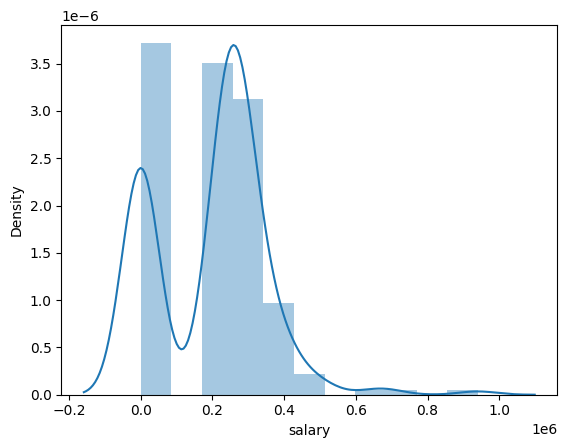

In [22]:
import seaborn as sns
dataset
sns.distplot(preprocessed['salary'])

d:\AI Projects\git-pro\Data-Science-Bivariate-Analysis\Bivariate.py:65: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True)


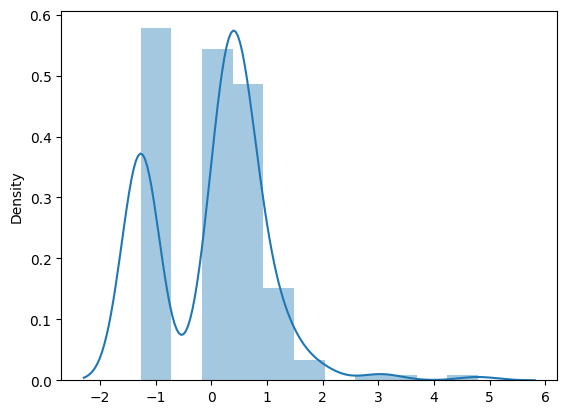

In [23]:
Bivariate.stdNBgraph(dataset['salary'])

# What is the probability Density Function of the salary range from 700000 to 900000?

d:\AI Projects\git-pro\Data-Science-Bivariate-Analysis\Bivariate.py:71: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax= sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


Mean=196870.968,Standard Deaviation=155233.760
The area between range (700000,900000):0.0005923853374033742


np.float64(0.0005923853374033742)

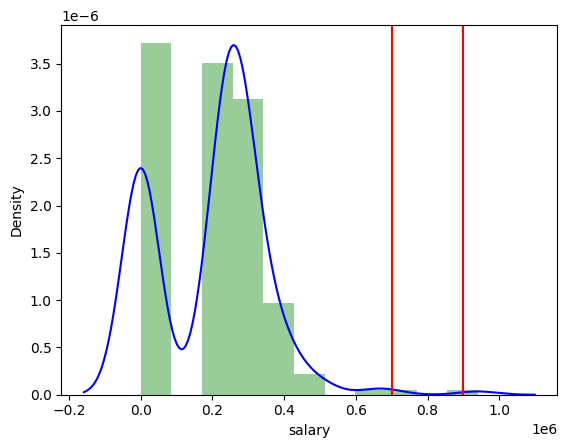

In [24]:
Bivariate.get_pdf_Probability(preprocessed['salary'],700000,900000)

# Test the similarity between the degree_t(Sci&Tech)with respect to etest_p and mba_p at significance level of 5%.(Make decision using Hypothesis Testing)

In [25]:
from scipy.stats import ttest_rel
result = ttest_rel(dataset[dataset['degree_t']=='Sci&Tech']['etest_p'],dataset[dataset['degree_t']=='Sci&Tech']['mba_p'])
p_value = result.pvalue.item()
print(p_value)
if p_value < alpha:
    print("Reject H0:there is significant difference between etest and mba test")
else:
    print("Fail to Reject H0:there is no significant difference between etest and mba test")

5.517920600505392e-06
Reject H0:there is significant difference between etest and mba test


# Which parameter is highly correlated with salary

In [26]:
preprocessed.corr(numeric_only=True)

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,1.000000,0.511472,0.538404,0.261993,0.388478,0.534030
hsc_p,0.511472,1.000000,0.434206,0.245113,0.354823,0.449155
degree_p,0.538404,0.434206,1.000000,0.224470,0.402364,0.405290
etest_p,0.261993,0.245113,0.224470,1.000000,0.218055,0.185577
mba_p,0.388478,0.354823,0.402364,0.218055,1.000000,0.138768
salary,0.534030,0.449155,0.405290,0.185577,0.138768,1.000000


#SSC_P having high correlation with salary

# Plot any useful graph and explain it

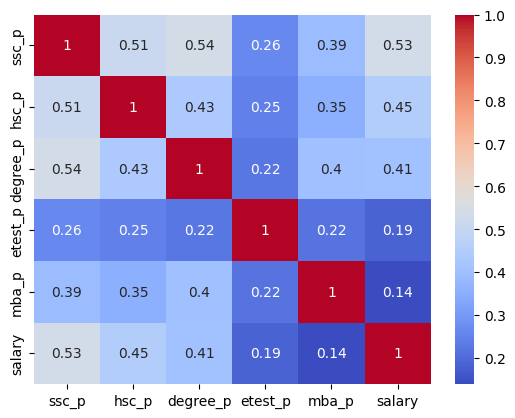

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = preprocessed[
    ['ssc_p','hsc_p','degree_p','etest_p','mba_p','salary']
].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

#Students who perform well in SSC, HSC, and Degree tend to perform somewhat better in MBA as well.



#Higher MBA marks do not necessarily translate into higher salaries in this dataset.


#etest has only weak correlation with other variables and which is not statistically significant for placement status